In [1]:
# ============================================================
# Imports & Configuration
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.svt import effective_rank
from config import RHO, MAX_ITER, TOL

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

# 1. Build a toy problem with known ground truth

In [2]:
rng = np.random.default_rng(42)
n = 20
rank = 2
m = 3 * rank * n     

#Build exact rank-2 matrix
U = rng.standard_normal((n, rank))
V = rng.standard_normal((n, rank))
X_true = U @ V.T

print(f"X_true shape: {X_true.shape}")
print(f"X_true rank: {np.linalg.matrix_rank(X_true)}")
print(f"Measurements: {m}  out of  {n*n}  possible  ({100*m/(n*n):.1f}%)")


X_true shape: (20, 20)
X_true rank: 2
Measurements: 120  out of  400  possible  (30.0%)


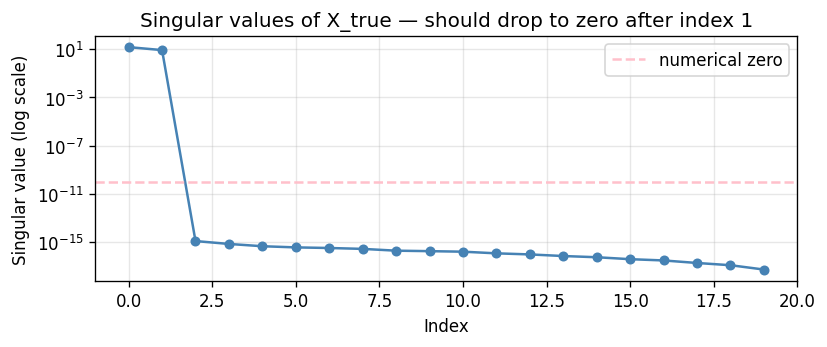

In [3]:
# Singular values of X_true — confirm exactly rank-2
sigma = np.linalg.svd(X_true, compute_uv=False)
plt.figure(figsize=(7, 3))
plt.semilogy(sigma, 'o-', color='steelblue', markersize=5)
plt.axhline(y=1e-10, color='pink', linestyle='--', label='numerical zero')
plt.title("Singular values of X_true — should drop to zero after index 1")
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-1,20)
plt.tight_layout()
plt.show()

# 2. Run the solver 

In [4]:
op = MeasurementOperator(n=n, m=m, seed=42)
y  = op.measure(X_true)

result = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER, tol=TOL,
                    X_true=X_true, verbose=True)

print(f"\nConverged: {result.converged}")
print(f"Iterations: {result.n_iters}")

Auto-scaled rho = 1.7289
     1     24.668420     46.242207      19    1.648561
     2     22.716929      1.900987      17    1.553451
     3      3.324316      1.699474      14    0.818119
     4      0.621598      1.550767      14    0.772354
     5      0.242538      1.264298      14    0.750645
    51      0.012457      0.148901       8    0.355673
   101      0.004500      0.045932       7    0.229130
   151      0.001312      0.011779       6    0.190648
   201      0.000313      0.002843       6    0.180735
   251      0.000075      0.000680       6    0.178330
   301      0.000018      0.000162       6    0.177754
   351      0.000004      0.000039       6    0.177617
   401      0.000001      0.000009       6    0.177584
   451      0.000000      0.000002       6    0.177576

Converged at iteration 479
Primal residual: 1.09e-07
Dual residual: 9.86e-07
Final rank: 6
  Relative error: 0.177575

Converged: True
Iterations: 479


# 3. Convergence plots

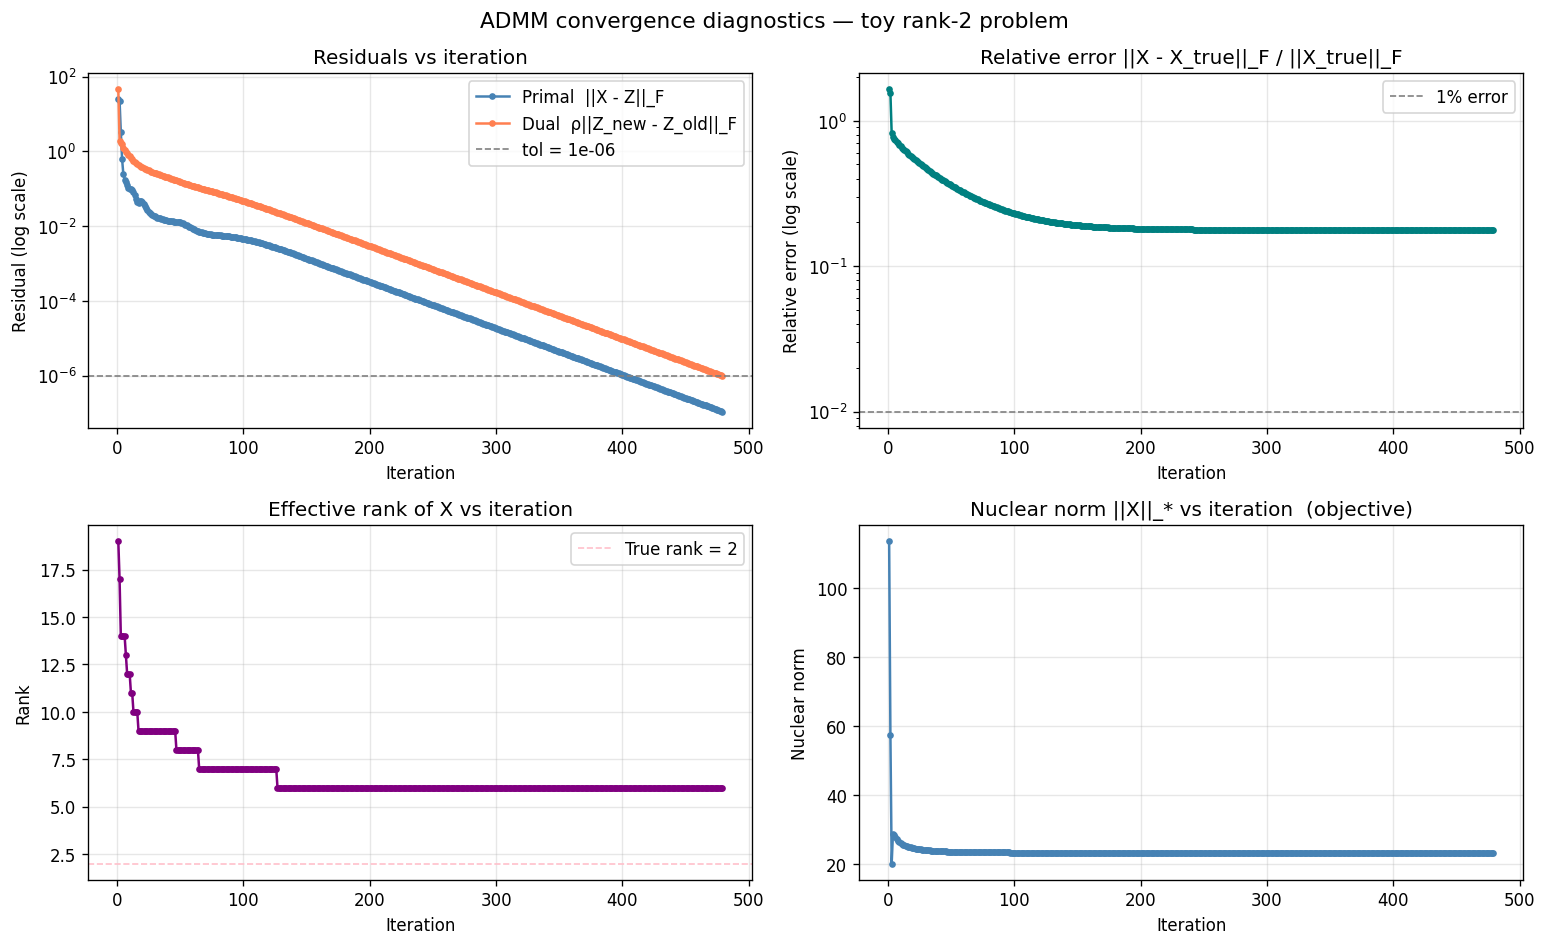

In [5]:
h = result.history
iters = range(1, result.n_iters + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Primal and dual residuals
axes[0, 0].semilogy(iters, h.primal_residuals, color='steelblue',
                    linewidth=1.5, label='Primal  ||X - Z||_F', marker='.',)
axes[0, 0].semilogy(iters, h.dual_residuals, color='coral',
                    linewidth=1.5, label='Dual  ρ||Z_new - Z_old||_F', marker='.',)
axes[0, 0].axhline(y=TOL, color='gray', linestyle='--', linewidth=1, label=f'tol = {TOL}')
axes[0, 0].set_title("Residuals vs iteration")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Residual (log scale)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Relative error vs X_true
axes[0, 1].semilogy(iters, h.rel_errors, color='teal', linewidth=1.5, marker='.')
axes[0, 1].axhline(y=1e-2, color='gray', linestyle='--', linewidth=1, label='1% error')
axes[0, 1].set_title("Relative error ||X - X_true||_F / ||X_true||_F")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Relative error (log scale)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Rank evolution
axes[1, 0].plot(iters, h.ranks, color='purple', linewidth=1.5, marker='.',)
axes[1, 0].axhline(y=rank, color='pink', linestyle='--', linewidth=1, 
                   label=f'True rank = {rank}')
axes[1, 0].set_title("Effective rank of X vs iteration")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Rank")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Nuclear norm (objective value)
axes[1, 1].plot(iters, h.objective_values, color='steelblue', linewidth=1.5, marker='.',)
axes[1, 1].set_title("Nuclear norm ||X||_* vs iteration  (objective)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Nuclear norm")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("ADMM convergence diagnostics — toy rank-2 problem", fontsize=13)
plt.tight_layout()
plt.show()

# 4. Visual recovery check

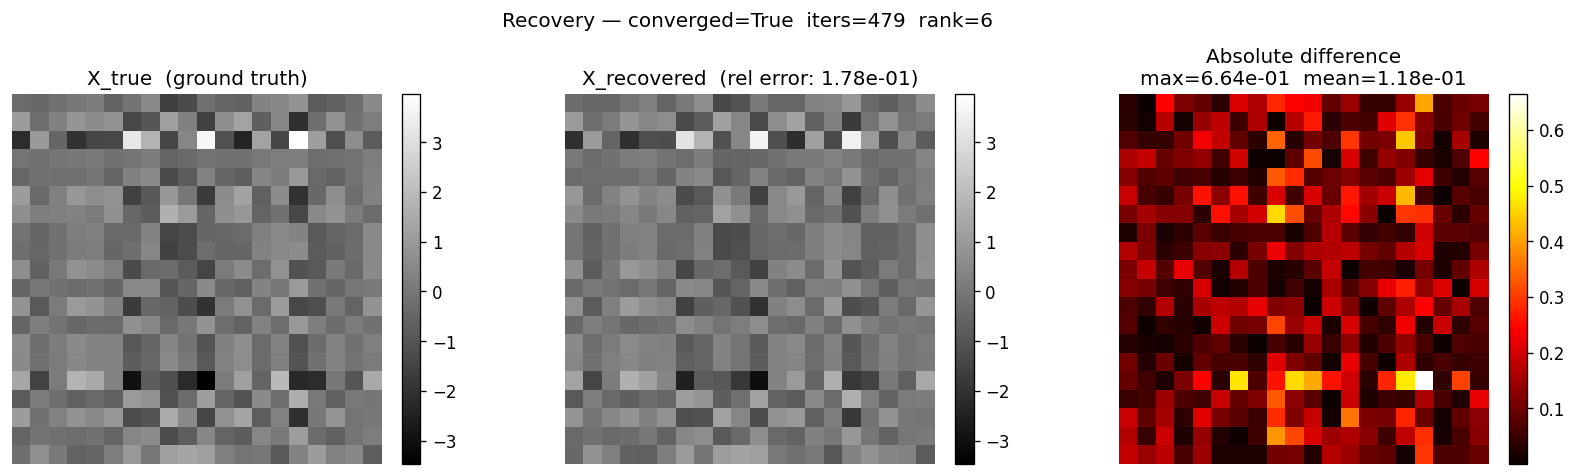

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmin = min(X_true.min(), result.X.min())
vmax = max(X_true.max(), result.X.max())

im0 = axes[0].imshow(X_true, vmin=vmin, vmax=vmax)
axes[0].set_title("X_true  (ground truth)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04) 

im1 = axes[1].imshow(result.X, vmin=vmin, vmax=vmax)
rel_err = np.linalg.norm(result.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
axes[1].set_title(f"X_recovered  (rel error: {rel_err:.2e})")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff = np.abs(result.X - X_true)
im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f"Absolute difference\nmax={diff.max():.2e}  mean={diff.mean():.2e}")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Recovery — converged={result.converged}  "
             f"iters={result.n_iters}  rank={effective_rank(result.X)}", fontsize=12)
plt.tight_layout()
plt.show()

# 5. Stress test: vary sampling ratio

m/(nxn) = 0.05  |  m =   41  |  rel_err = 0.8922  |  converged = True
m/(nxn) = 0.10  |  m =   41  |  rel_err = 0.8922  |  converged = True
m/(nxn) = 0.20  |  m =   80  |  rel_err = 0.6759  |  converged = True
m/(nxn) = 0.30  |  m =  120  |  rel_err = 0.1776  |  converged = True
m/(nxn) = 0.50  |  m =  200  |  rel_err = 0.0000  |  converged = True
m/(nxn) = 0.75  |  m =  300  |  rel_err = 0.0000  |  converged = True


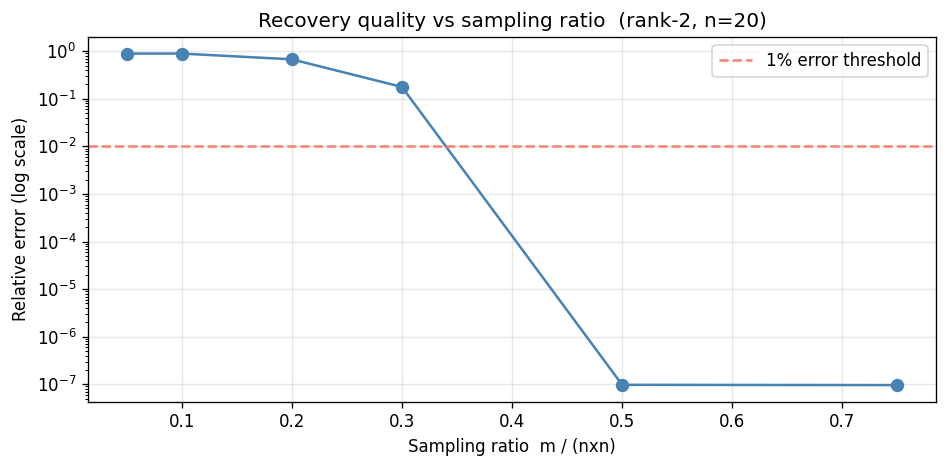

In [7]:
# How does recovery quality change as you give the solver more or fewer measurements?

sampling_ratios = [0.05, 0.10, 0.20, 0.30, 0.50, 0.75]
rel_errors_sweep = []

for ratio in sampling_ratios:
    m_sweep = max(rank * n + 1, int(ratio * n * n))
    op_sweep = MeasurementOperator(n=n, m=m_sweep, seed=42)
    y_sweep  = op_sweep.measure(X_true)
    res      = admm_solve(op_sweep, y_sweep, verbose=False)
    err      = np.linalg.norm(res.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
    rel_errors_sweep.append(err)
    print(f"m/(nxn) = {ratio:.2f}  |  m = {m_sweep:4d}  |  "
          f"rel_err = {err:.4f}  |  converged = {res.converged}")

plt.figure(figsize=(8, 4))
plt.semilogy(sampling_ratios, rel_errors_sweep, 'o-',
             color='steelblue', linewidth=1.5, markersize=7)
plt.axhline(y=1e-2, color='salmon', linestyle='--', label='1% error threshold')
plt.xlabel("Sampling ratio  m / (nxn)")
plt.ylabel("Relative error (log scale)")
plt.title("Recovery quality vs sampling ratio  (rank-2, n=20)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Extra Tests

In [8]:
sigma_recovered = np.linalg.svd(result.X, compute_uv=False)
sigma_true = np.linalg.svd(X_true, compute_uv=False)

print("True singular values:", np.round(sigma_true, 4))
print("Recovered singular values:", np.round(sigma_recovered, 4))
print(f"\neffective_rank with tol=1e-6 : {effective_rank(result.X, tol=1e-6)}")
print(f"effective_rank with tol=1e-3 : {effective_rank(result.X, tol=1e-3)}")
print(f"effective_rank with tol=1e-2 : {effective_rank(result.X, tol=1e-2)}")

True singular values: [14.9784  8.4883  0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.    ]
Recovered singular values: [13.7726  7.2872  0.8439  0.6983  0.3489  0.2832  0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.    ]

effective_rank with tol=1e-6 : 6
effective_rank with tol=1e-3 : 6
effective_rank with tol=1e-2 : 6


In [9]:
# Force a fresh run with extreme settings to confirm solver is actually running
op_dbg = MeasurementOperator(n=n, m=m, seed=42)
y_dbg  = op_dbg.measure(X_true)

result_dbg = admm_solve(op_dbg, y_dbg, rho=5.0, max_iter=10, 
                         tol=1e-12, X_true=X_true, verbose=True)

Auto-scaled rho = 5.0000
     1     26.006393    133.608547      20    1.723236
     2     25.322235      2.111880      19    1.689137
     3      1.280577      2.063127      18    0.823578
     4      0.085858      1.960344      18    0.810495
     5      0.042038      1.809052      17    0.801438

Did not converge in 10 iterations.
Final primal residual : 4.04e-02
Final dual residual   : 1.21e+00


In [10]:
# Test z_update in isolation
X_test = np.zeros((n, n))
Lam_test = np.zeros((n, n))

Z_test = op_dbg.z_update(X_test, Lam_test, y_dbg, rho=1.0)

print("Z_test after one z_update:")
print(f"  norm : {np.linalg.norm(Z_test):.4f}")
print(f"  A(Z) - y residual : {np.linalg.norm(op_dbg.forward(Z_test) - y_dbg):.2e}")

# If A(Z) = y is satisfied, this residual should be ~1e-10
# If Z_test is all zeros or tiny, z_update is broken

Z_test after one z_update:
  norm : 9.4062
  A(Z) - y residual : 1.28e-14


In [11]:
from src.svt import svt

# Simulate one X update from a nonzero Z
Z_test2 = op_dbg.adjoint(y_dbg)    # use backprojection as a nonzero starting point
Lam_test2 = np.zeros((n, n))
rho_test = 1.0

X_test2 = svt(Z_test2 - Lam_test2 / rho_test, 1.0 / rho_test)

sigma_in  = np.linalg.svd(Z_test2, compute_uv=False)
sigma_out = np.linalg.svd(X_test2, compute_uv=False)

print("Input  singular values (top 6):", np.round(sigma_in[:6], 4))
print("Output singular values (top 6):", np.round(sigma_out[:6], 4))
print("Difference (should show thresholding):", np.round(sigma_in[:6] - sigma_out[:6], 4))

Input  singular values (top 6): [17.8489 12.9449 11.0344 10.0685  9.7564  9.5524]
Output singular values (top 6): [16.8489 11.9449 10.0344  9.0685  8.7564  8.5524]
Difference (should show thresholding): [1. 1. 1. 1. 1. 1.]
